In [2]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import importlib
from keras.models import Model
from keras.layers import (Input, Dense, Dropout, Conv1D, GlobalAveragePooling1D, GaussianNoise,
                        BatchNormalization, Activation, Add,)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

import utils, Augmentation
importlib.reload(utils)
importlib.reload(Augmentation)

from Augmentation import (Noise_aug, filter_short_sequences,
prepare_sequence, AvgPair_segments, TimeShift_aug, TimeMask_aug, cap_long_seq, Scale_aug, PerChannelFluxShift_aug
,gp_impute_and_augment_channels)

from utils import (plot_metric_curve, find_best_f1score_and_threshold, labels_weight, set_seed
                   ,load_data, plot_confusion_matrix, drop_column, evaluate_and_save_metrics_binary
                   , plot_2xN_confusion_matrix, drop_unnecessary_columns, plot_tde_reconstruction)

In [3]:
# Load the data
dir = f'{os.getcwd().replace("\\", "/")}/Data/Processed Data'
df = pd.read_csv(f"{dir}/total_df.csv")
df = drop_unnecessary_columns([df])[0]
df.drop(columns=['target'], inplace=True)
print(df.shape)
df.head()

(975914, 14)


,object_id,Time (MJD),Filter_z_flux,Filter_z_flux_err,Filter_r_flux,Filter_r_flux_err,Filter_y_flux,Filter_y_flux_err,Filter_i_flux,Filter_i_flux_err,Filter_g_flux,Filter_g_flux_err,Filter_u_flux,Filter_u_flux_err
0,Dornhoth_fervain_onodrim,63314.4662,-1.895487,0.425312,0.000000,0.000000,-1.601633,1.191244,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,Dornhoth_fervain_onodrim,63327.6691,-1.811662,0.462278,0.000000,0.000000,0.000000,0.000000,-1.709337,0.389580,0.000000,0.000000,0.0,0.0
2,Dornhoth_fervain_onodrim,63340.8720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.495971,0.403594,0.000000,0.000000,0.0,0.0
3,Dornhoth_fervain_onodrim,63380.4806,0.000000,0.000000,-1.328391,0.225768,0.000000,0.000000,0.000000,0.000000,-1.253124,0.255106,0.0,0.0
4,Dornhoth_fervain_onodrim,63420.0891,0.000000,0.000000,-1.396016,0.576872,0.000000,0.000000,0.000000,0.000000,-0.693107,0.241171,0.0,0.0


In [4]:
import numpy as np
import pandas as pd

def prepare_masked_sequences(df, max_len=100):
    """
    Groups the dataframe by object_id, calculates delta_t, 
    and generates padded tensors for Flux, Delta_T, and Mask.
    """
    # Identify flux and error columns
    flux_cols = [c for c in df.columns if 'flux' in c and 'err' not in c]
    
    grouped = df.groupby('object_id')
    num_objects = len(grouped)
    
    # Initialize zero arrays: Shape (samples, sequence_length, features)
    X_flux = np.zeros((num_objects, max_len, 6))
    X_dt = np.zeros((num_objects, max_len, 1))
    X_mask = np.zeros((num_objects, max_len, 6))
    
    for idx, (obj_id, group) in enumerate(grouped):
        # Sort by MJD to ensure correct temporal sequence
        group = group.sort_values('Time (MJD)')
        seq_len = min(len(group), max_len)
        
        # 1. Extract Fluxes
        flux_data = group[flux_cols].values[:seq_len]
        X_flux[idx, :seq_len, :] = flux_data
        
        # 2. Calculate Delta Time (MJD differences)
        mjd = group['Time (MJD)'].values[:seq_len]
        dt = np.zeros_like(mjd)
        if len(mjd) > 1:
            dt[1:] = np.diff(mjd)
        X_dt[idx, :seq_len, 0] = dt
        
        # 3. Construct Binary Mask (1 if observed/non-zero, 0 if missing/zero)
        # We assume flux is missing if it is exactly 0.0
        mask_data = (flux_data != 0.0).astype(float)
        X_mask[idx, :seq_len, :] = mask_data
        
    return X_flux, X_dt, X_mask

In [5]:
import tensorflow as tf
from tensorflow.keras.losses import Loss

class MaskedMSE(tf.keras.losses.Loss):
    def __init__(self, name="masked_mse", **kwargs):
        super().__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        # y_true contains:
        # channels 0-5: True Flux
        # channels 6-11: Binary Mask (1 for observed, 0 for missing)
        true_flux = y_true[:, :, :6]
        mask = y_tf = y_true[:, :, 6:]
        
        # Calculate squared error
        squared_errors = tf.square(true_flux - y_pred)
        
        # Apply mask to errors
        masked_errors = squared_errors * mask
        
        # Calculate mean over only observed points
        loss = tf.reduce_sum(masked_errors) / (tf.reduce_sum(mask) + 1e-8)
        return loss

# Original Simple Model

In [6]:
from tensorflow.keras.layers import Input, Concatenate, GRU, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model

def build_masked_autoencoder(max_len=100, latent_dim=32):
    # Inputs
    flux_input = Input(shape=(max_len, 6), name="flux_input")
    dt_input = Input(shape=(max_len, 1), name="delta_t_input")
    mask_input = Input(shape=(max_len, 6), name="mask_input")
    
    # Concatenate inputs at each time step
    merged_input = Concatenate(axis=-1, name="feature_fusion")([flux_input, dt_input, mask_input])
    
    # ── ENCODER ──────────────────────────────────────────────────────────────
    # GRU handles the sequence modeling over irregular time steps
    encoder_gru = GRU(64, return_sequences=False, name="encoder_gru")(merged_input)
    latent_space = Dense(latent_dim, activation="relu", name="latent_bottleneck")(encoder_gru)
    
    # ── DECODER ──────────────────────────────────────────────────────────────
    # Reconstruct the sequence from the latent vector representation
    decoder_repeater = RepeatVector(max_len, name="decoder_repeater")(latent_space)
    decoder_gru = GRU(64, return_sequences=True, name="decoder_gru")(decoder_repeater)
    
    # Output 6 channels representing the continuous reconstructed fluxes
    reconstructed_flux = TimeDistributed(Dense(6, activation="linear"), name="reconstructed_flux")(decoder_gru)
    
    model = Model(inputs=[flux_input, dt_input, mask_input], outputs=reconstructed_flux)
    return model

In [7]:
# Prepare your dataset arrays (assume df is your loaded pandas dataframe)
X_flux, X_dt, X_mask = prepare_masked_sequences(df, max_len=100)

# Concatenate targets: True fluxes (0-5) and the mask (6-11)
Y_train = np.concatenate([X_flux, X_mask], axis=-1)

# Build and compile
autoencoder = build_masked_autoencoder(max_len=100, latent_dim=32)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    verbose=1,
    restore_best_weights=True,
    mode="min",
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1,
    mode="min",
    min_lr=1e-6,
)

autoencoder.compile(
        optimizer=Adam(
        learning_rate=0.0001,
        gradient_accumulation_steps=4), 
        loss=MaskedMSE()
        )

# Fit the model
history = autoencoder.fit(
    x=[X_flux, X_dt, X_mask],
    y=Y_train,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    validation_split=0.2,
)

Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 46s 127ms/step - loss: 6.6932 - val_loss: 10.4495 - learning_rate: 1.0000e-04
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - loss: 6.5829 - val_loss: 10.3324 - learning_rate: 1.0000e-04
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - loss: 6.4255 - val_loss: 10.1528 - learning_rate: 1.0000e-04
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - loss: 6.2289 - val_loss: 9.9479 - learning_rate: 1.0000e-04
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - loss: 6.1098 - val_loss: 9.8542 - learning_rate: 1.0000e-04
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - loss: 6.0265 - val_loss: 9.7548 - learning_rate: 1.0000e-04
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - loss: 5.9036 - val_loss: 9.6138 - learning_rate: 1.0000e-04
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - loss: 5.7566 - val_loss: 9.3975 - learning_rate: 1.0000e-04
Epoch 9/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/st

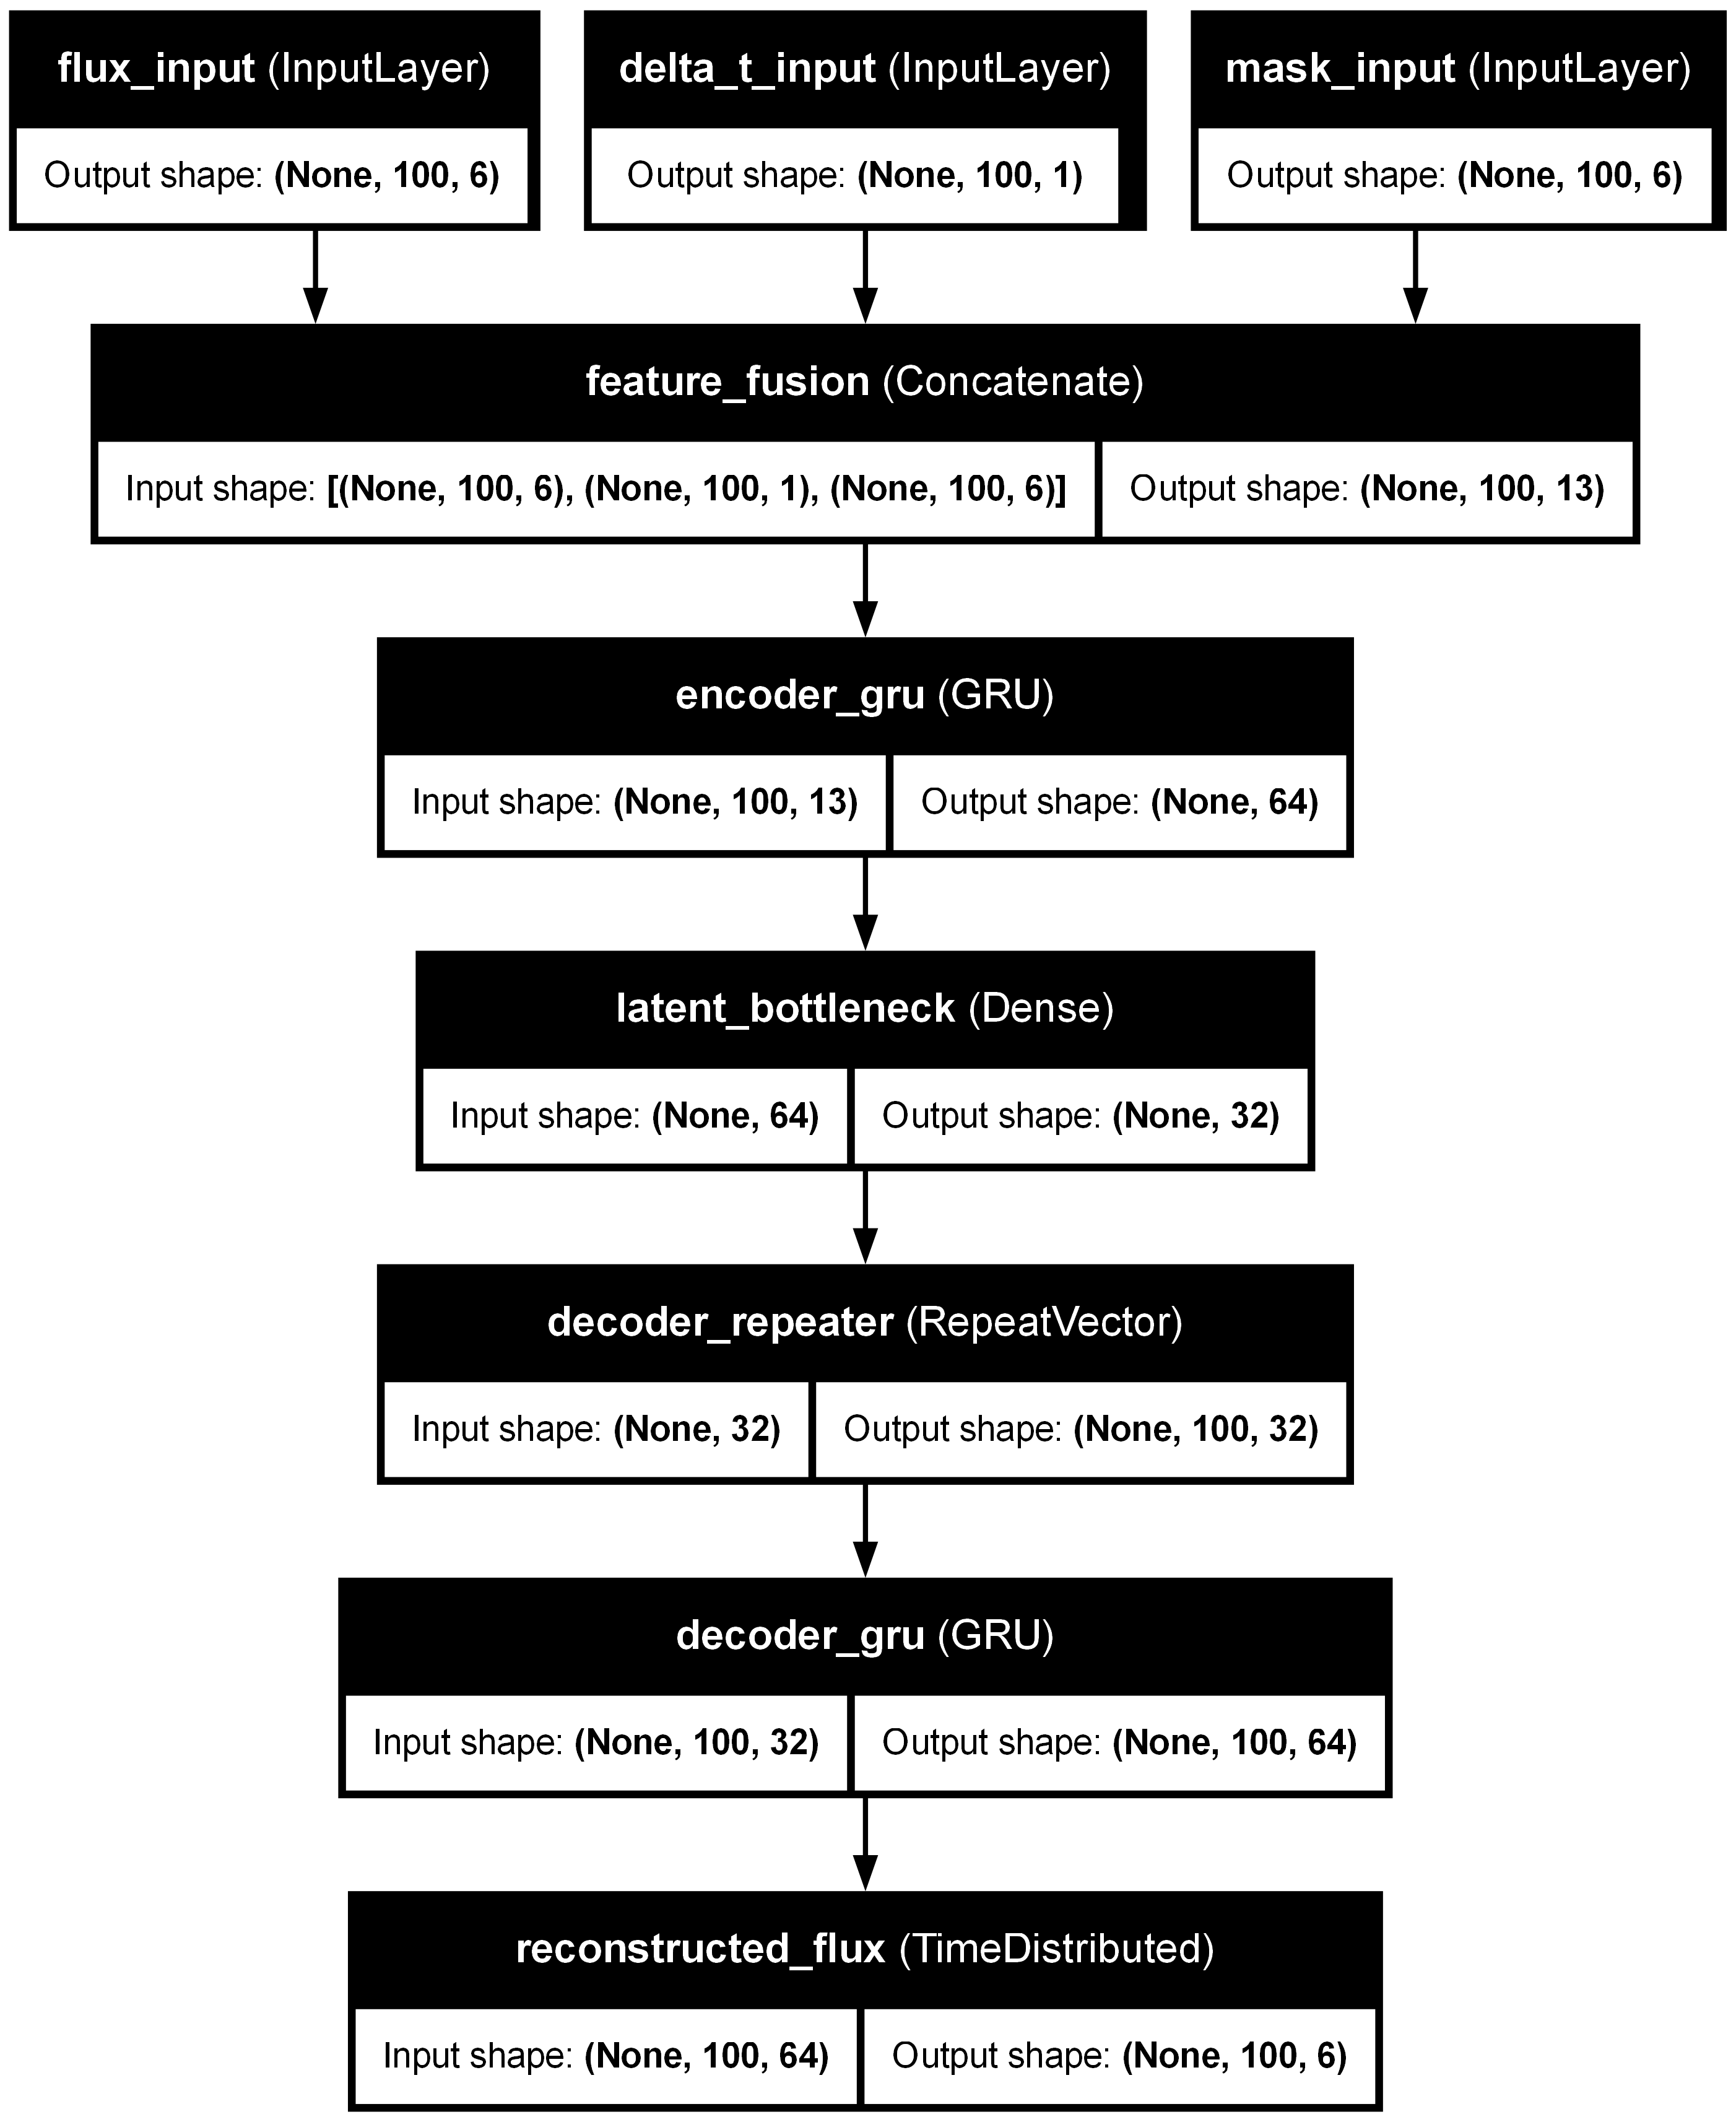

In [8]:
from keras.utils import plot_model
plot_model(
    autoencoder,
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",          # TB = top-bottom, LR = left-right
    expand_nested=False,
    dpi=300
)

TDE
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


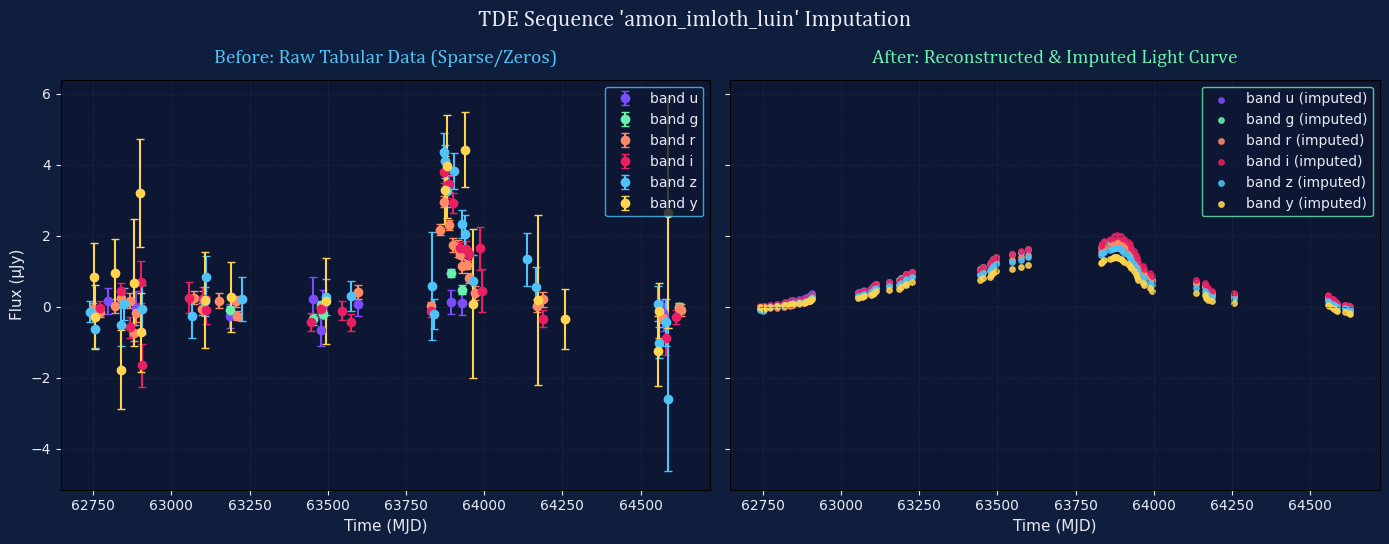

AGN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


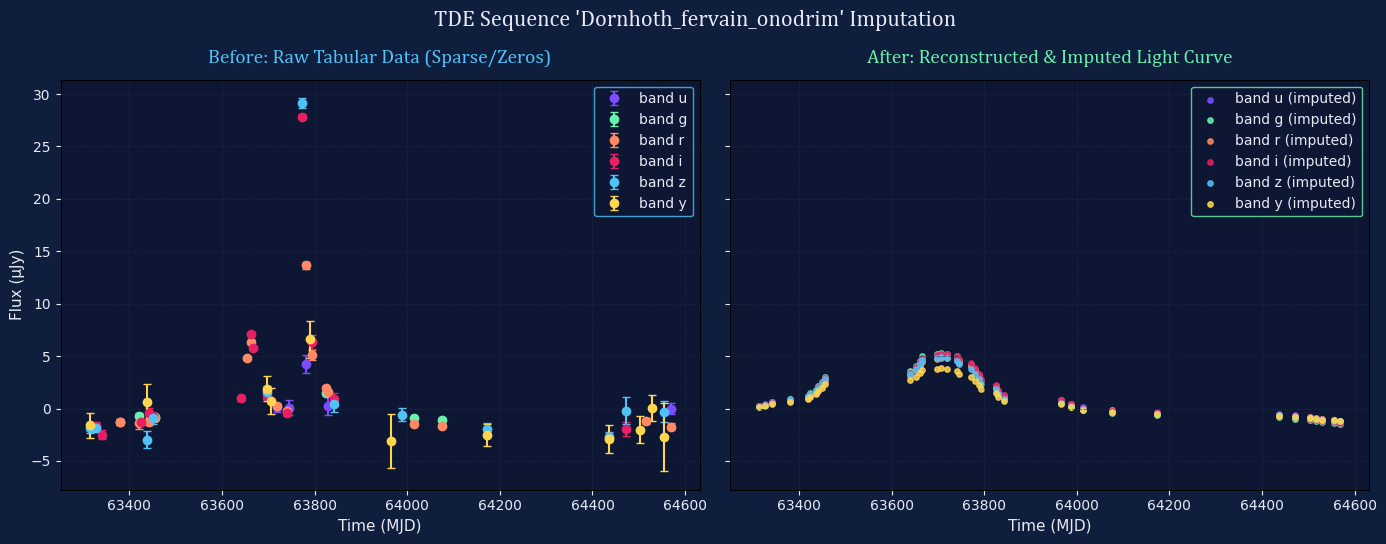

In [9]:
print("TDE")
plot_tde_reconstruction(autoencoder, object_id="amon_imloth_luin", df=df, max_len=100)
print("AGN")
plot_tde_reconstruction(autoencoder, object_id="Dornhoth_fervain_onodrim", df=df, max_len=100)

# VAE Model

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.backend import random_normal

# ── 1. CUSTOM SAMPLING LAYER ─────────────────────────────────────────────────
class Sampling(layers.Layer):
    """
    Takes the mean (z_mean) and log variance (z_log_var) from the encoder 
    and samples a random vector z using the reparameterization trick.
    """
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # Generate random Gaussian noise
        epsilon = random_normal(shape=(batch, dim))
        # z = mean + std_dev * epsilon
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# ── 2. COMPREHENSIVE TIME-CONDITIONED MASKED VAE ─────────────────────────────
class MaskedVAE(Model):
    def __init__(self, max_len=100, latent_dim=64, kl_beta=0.01, **kwargs):
        """
        kl_beta: Scaling factor for KL loss. Keep low (e.g., 0.01) to prevent
                 posterior collapse (flat curve reconstruction issues).
        """
        super().__init__(**kwargs)
        self.max_len = max_len
        self.latent_dim = latent_dim
        self.kl_beta = kl_beta
        
        # ── ENCODER NETWORK ──
        self.concat = layers.Concatenate(axis=-1)
        self.enc_gru_1 = layers.Bidirectional(layers.GRU(128, return_sequences=True, name="enc_gru_1"))
        self.enc_gru_2 = layers.GRU(128, return_sequences=False, name="enc_gru_2")
        
        self.z_mean = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var = layers.Dense(latent_dim, name="z_log_var")
        self.sampling = Sampling(name="sampling")
        
        # ── DECODER NETWORK ──
        self.repeat = layers.RepeatVector(max_len, name="decoder_repeater")
        self.dec_gru_1 = layers.GRU(128, return_sequences=True, name="dec_gru_1")
        self.dec_gru_2 = layers.GRU(64, return_sequences=True, name="dec_gru_2")
        self.dense_out = layers.TimeDistributed(layers.Dense(6, activation="linear"), name="reconstructed_flux")
        
        # Metric Trackers
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        """Standard forward pass definition used during inference/testing."""
        flux_in, dt_input, mask_input = inputs
        
        # 1. Encode
        merged = self.concat([flux_in, dt_input, mask_input])
        x = self.enc_gru_1(merged)
        x = self.enc_gru_2(x)
        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)
        z = self.sampling([z_mean, z_log_var])
        
        # 2. Decode with Time-Conditioning
        rep_z = self.repeat(z)
        dec_merged = self.concat([rep_z, dt_input]) # Concat time-deltas to decoder input
        x_dec = self.dec_gru_1(dec_merged)
        x_dec = self.dec_gru_2(x_dec)
        return self.dense_out(x_dec)

    def train_step(self, data):
        """Custom optimization step executed during model.fit()"""
        inputs, y_true = data
        flux_in, dt_input, mask_input = inputs
        
        true_flux = y_true[:, :, :6]
        mask = y_true[:, :, 6:]
        
        with tf.GradientTape() as tape:
            # 1. Encode
            merged = self.concat([flux_in, dt_input, mask_input])
            x = self.enc_gru_1(merged)
            x = self.enc_gru_2(x)
            z_mean = self.z_mean(x)
            z_log_var = self.z_log_var(x)
            z = self.sampling([z_mean, z_log_var])
            
            # 2. Decode
            rep_z = self.repeat(z)
            dec_merged = self.concat([rep_z, dt_input])
            x_dec = self.dec_gru_1(dec_merged)
            x_dec = self.dec_gru_2(x_dec)
            y_pred = self.dense_out(x_dec)
            
            # 3. Calculate Loss
            # A: Custom Masked MSE Reconstruction Loss
            squared_errors = tf.square(true_flux - y_pred)
            masked_errors = squared_errors * mask
            recon_loss = tf.reduce_sum(masked_errors) / (tf.reduce_sum(mask) + 1e-8)
            
            # B: Kullback-Leibler Divergence Loss
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            # Combine losses
            total_loss = recon_loss + (self.kl_beta * kl_loss) 

        # Apply gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        # Update metric trackers
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        """Custom evaluation step executed during model.evaluate() and validation runs."""
        inputs, y_true = data
        flux_in, dt_input, mask_input = inputs
        
        true_flux = y_true[:, :, :6]
        mask = y_true[:, :, 6:]
        
        # Forward pass
        merged = self.concat([flux_in, dt_input, mask_input])
        x = self.enc_gru_1(merged)
        x = self.enc_gru_2(x)
        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)
        z = self.sampling([z_mean, z_log_var])
        
        rep_z = self.repeat(z)
        dec_merged = self.concat([rep_z, dt_input])
        x_dec = self.dec_gru_1(dec_merged)
        x_dec = self.dec_gru_2(x_dec)
        y_pred = self.dense_out(x_dec)
        
        # Calculate losses
        squared_errors = tf.square(true_flux - y_pred)
        masked_errors = squared_errors * mask
        recon_loss = tf.reduce_sum(masked_errors) / (tf.reduce_sum(mask) + 1e-8)
        
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        
        total_loss = recon_loss + (self.kl_beta * kl_loss) 
        
        # Update trackers
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [ ]:
# Build VAE Model
vae_model = MaskedVAE(max_len=100, latent_dim=64, kl_beta=0.01)

# Compile using Keras optimizer
vae_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Y_train must contain target fluxes in channels 0-5 and masks in channels 6-11
Y_train = np.concatenate([X_flux, X_mask], axis=-1)

# Train VAE
vae_model.fit(
    x=[X_flux, X_dt, X_mask],
    y=Y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 114s 739ms/step - kl_loss: 4.4678 - loss: 6.0225 - recon_loss: 5.9779 - val_kl_loss: 5.0921 - val_loss: 9.0293 - val_recon_loss: 8.9784
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 97s 760ms/step - kl_loss: 6.6189 - loss: 5.2800 - recon_loss: 5.2139 - val_kl_loss: 6.8802 - val_loss: 8.6305 - val_recon_loss: 8.5617
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 112s 874ms/step - kl_loss: 8.5255 - loss: 4.8260 - recon_loss: 4.7407 - val_kl_loss: 9.1983 - val_loss: 7.9950 - val_recon_loss: 7.9030
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 115s 901ms/step - kl_loss: 9.9197 - loss: 4.4933 - recon_loss: 4.3941 - val_kl_loss: 12.9001 - val_loss: 7.9391 - val_recon_loss: 7.8101
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 114s 890ms/step - kl_loss: 11.1895 - loss: 4.3193 - recon_loss: 4.2074 - val_kl_loss: 11.7844 - val_loss: 7.6679 - val_recon_loss: 7.5501
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 116s 908ms/step - kl_loss: 12.6772 - loss: 3.9889 - recon_loss: 3.8621 -

In [ ]:
print("TDE")
plot_tde_reconstruction(vae_model, object_id="amon_imloth_luin", df=df, max_len=100)
print("AGN")
plot_tde_reconstruction(vae_model, object_id="Dornhoth_fervain_onodrim", df=df, max_len=100)

# Expanded AE using GRU and Bidirectional

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Concatenate, GRU, Bidirectional, RepeatVector, TimeDistributed, Dense, Dropout

# ── 1. STANDALONE CUSTOM MASKED LOSS FUNCTION ────────────────────────────────
def masked_mse_loss(y_true, y_pred):
    """
    Computes loss strictly over observed coordinates.
    y_true has 12 channels (0-5: flux values, 6-11: binary mask).
    y_pred has 6 channels (predicted flux).
    """
    true_flux = y_true[:, :, :6]
    mask = y_true[:, :, 6:]
    
    squared_errors = tf.square(true_flux - y_pred)
    masked_errors = squared_errors * mask
    
    # Return mean error over observed points
    return tf.reduce_sum(masked_errors) / (tf.reduce_sum(mask) + 1e-8)

# ── 2. STACKED ATTENTION AUTOENCODER MODEL BUILDER ───────────────────────────
def build_stacked_attention_autoencoder(max_len=100, latent_dim=64):
    # Inputs
    flux_input = Input(shape=(max_len, 6), name="flux_input")
    dt_input = Input(shape=(max_len, 1), name="delta_t_input")
    mask_input = Input(shape=(max_len, 6), name="mask_input")
    
    # ── ENCODER ──
    # Fuse input channels
    merged_input = Concatenate(axis=-1, name="fusion_input")([flux_input, dt_input, mask_input])
    
    # Layer 1: Bidirectional GRU to capture forward/backward context
    x = Bidirectional(GRU(128, return_sequences=True, name="enc_bigru_1"))(merged_input)
    x = Dropout(0.2, name="dropout_enc_1")(x)
    
    # Layer 2: Deep GRU to compress sequences
    x = GRU(128, return_sequences=False, name="enc_gru_2")(x)
    x = Dropout(0.2, name="dropout_enc_2")(x)
    
    # Latent Feature Bottleneck
    latent_space = Dense(latent_dim, activation="relu", name="latent_bottleneck")(x)
    
    # ── DECODER with Time-Conditioning ──
    # 1. Repeat latent space across sequence steps
    repeated_z = RepeatVector(max_len, name="decoder_repeater")(latent_space)
    
    # 2. Inject temporal gaps directly to Decoder input (Time-awareness)
    decoder_input = Concatenate(axis=-1, name="time_conditioning")([repeated_z, dt_input])
    
    # Layer 1: Deep GRU Decoder
    x_dec = GRU(128, return_sequences=True, name="dec_gru_1")(decoder_input)
    x_dec = Dropout(0.2, name="dropout_dec_1")(x_dec)
    
    # Layer 2: Secondary GRU Decoder for refining curves
    x_dec = GRU(64, return_sequences=True, name="dec_gru_2")(x_dec)
    
    # Dense Projection to Output Channels
    reconstructed_flux = TimeDistributed(Dense(6, activation="linear"), name="reconstructed_flux")(x_dec)
    
    # Compile model using Functional API structure
    model = Model(inputs=[flux_input, dt_input, mask_input], outputs=reconstructed_flux, name="Stacked_Attention_AE")
    return model

In [ ]:
# Build Stacked Autoencoder Model
ae_model = build_stacked_attention_autoencoder(max_len=100, latent_dim=64)

# Compile using Keras Functional standard
ae_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=masked_mse_loss
)

# Y_train must contain target fluxes in channels 0-5 and masks in channels 6-11
Y_train = np.concatenate([X_flux, X_mask], axis=-1)

# Train Autoencoder
ae_model.fit(
    x=[X_flux, X_dt, X_mask],
    y=Y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 107s 709ms/step - loss: 5.9130 - val_loss: 8.7723
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 78s 612ms/step - loss: 4.9763 - val_loss: 8.0163
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 80s 622ms/step - loss: 4.4307 - val_loss: 7.5665
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 87s 679ms/step - loss: 4.1047 - val_loss: 7.4917
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 99s 772ms/step - loss: 4.0269 - val_loss: 7.3005
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 100s 781ms/step - loss: 3.7899 - val_loss: 7.1189
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 109s 853ms/step - loss: 3.5191 - val_loss: 6.8207
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 103s 800ms/step - loss: 3.4999 - val_loss: 6.6364
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 715ms/step - loss: 3.3285 - val_loss: 6.7826
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 703ms/step - loss: 3.3524 - val_loss: 7.2327
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 90s 703ms/step - loss: 3.1637 - val_loss: 6.6759
Epoc

KeyboardInterrupt: 

In [ ]:
print("TDE")
plot_tde_reconstruction(ae_model, object_id="amon_imloth_luin", df=df, max_len=100)
print("AGN")
plot_tde_reconstruction(ae_model, object_id="Dornhoth_fervain_onodrim", df=df, max_len=100)